In [2]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="ecommerce_analytics"
)

print("MySQL connection successful!")

MySQL connection successful!


In [4]:
query = """
SELECT *
FROM customers
"""

customers_df = pd.read_sql(query, connection)
query = """
SELECT *
FROM products
"""

products_df = pd.read_sql(query, connection)

query = """
SELECT *
FROM orders
"""

orders_df = pd.read_sql(query, connection)

query = """
SELECT *
FROM order_items
"""

order_items_df = pd.read_sql(query, connection)

query = """
SELECT *
FROM payments
"""

payments_df = pd.read_sql(query, connection)

customers_df.head()

C:\Users\suman\AppData\Local\Temp\ipykernel_20868\1557810408.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers_df = pd.read_sql(query, connection)
C:\Users\suman\AppData\Local\Temp\ipykernel_20868\1557810408.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products_df = pd.read_sql(query, connection)
C:\Users\suman\AppData\Local\Temp\ipykernel_20868\1557810408.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql(query, connection)
C:\Users\suman\AppData\Local\Temp\ipykernel_20868\1557

,customer_id,first_name,last_name,gender,age,city,state,country,signup_date,customer_segment
0,1,Customer1,User1,Male,65,Bengaluru,Karnataka,India,2024-07-17,Regular
1,2,Customer2,User2,Male,65,Mumbai,Maharashtra,India,2023-07-29,VIP
2,3,Customer3,User3,Female,20,Bengaluru,Karnataka,India,2023-03-03,Regular
3,4,Customer4,User4,Male,50,Mumbai,Maharashtra,India,2023-02-24,VIP
4,5,Customer5,User5,Female,32,Mumbai,Maharashtra,India,2025-07-08,VIP


In [5]:
customers_df
print(products_df.head())
print(print(orders_df.head()))
print(order_items_df.head())
print(payments_df.head())

   product_id         product_name     category subcategory    brand  \
0           1      Decor Product 1         Home       Decor  Brand E   
1           2     Mobile Product 2  Electronics      Mobile  Brand C   
2           3      Shirt Product 3      Fashion       Shirt  Brand A   
3           4   Skincare Product 4       Beauty    Skincare  Brand A   
4           5  Furniture Product 5         Home   Furniture  Brand B   

   unit_cost  unit_price  
0   14430.61    23891.91  
1    4848.45     7809.11  
2    8792.64    11070.51  
3   13941.22    24286.36  
4    6008.68     8561.80  
   order_id  customer_id  order_date shipping_date order_status shipping_city  \
0         1           80  2026-02-06    2026-02-12    Delivered     Bengaluru   
1         2          144  2026-01-21    2026-01-24    Delivered       Chennai   
2         3          166  2026-03-10    2026-03-11    Delivered     Ahmedabad   
3         4           47  2026-03-12    2026-03-19    Delivered        Jaipur   


In [6]:
print("Customers:", customers_df.shape)
print("Products:", products_df.shape)
print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Payments:", payments_df.shape)


Customers: (200, 10)
Products: (100, 7)
Orders: (300, 7)
Order Items: (300, 6)
Payments: (300, 6)


In [7]:
# Check missing values in each table

print("CUSTOMERS")
print(customers_df.isnull().sum())

print("\nPRODUCTS")
print(products_df.isnull().sum())

print("\nORDERS")
print(orders_df.isnull().sum())

print("\nORDER ITEMS")
print(order_items_df.isnull().sum())

print("\nPAYMENTS")
print(payments_df.isnull().sum())

CUSTOMERS
customer_id         0
first_name          0
last_name           0
gender              0
age                 0
city                0
state               0
country             0
signup_date         0
customer_segment    0
dtype: int64

PRODUCTS
product_id      0
product_name    0
category        0
subcategory     0
brand           0
unit_cost       0
unit_price      0
dtype: int64

ORDERS
order_id           0
customer_id        0
order_date         0
shipping_date     30
order_status       0
shipping_city      0
shipping_state     0
dtype: int64

ORDER ITEMS
order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
discount         0
dtype: int64

PAYMENTS
payment_id        0
order_id          0
payment_date      0
payment_method    0
payment_status    0
payment_amount    0
dtype: int64


In [10]:
print("Customer duplicates:", customers_df.duplicated().sum()) 
print("Product duplicates:", products_df.duplicated().sum())
print("Order duplicates:", orders_df.duplicated().sum())
print("Order item dulicates:", order_items_df.duplicated().sum())
print("Payment duplicates:", payments_df.duplicated().sum())

Customer duplicates: 0
Product duplicates: 0
Order duplicates: 0
Order item dulicates: 0
Payment duplicates: 0


In [13]:
print(customers_df.dtypes)
print(products_df.dtypes) 
print(orders_df.dtypes)
print(order_items_df.dtypes)
print(payments_df.dtypes)

customer_id          int64
first_name          object
last_name           object
gender              object
age                  int64
city                object
state               object
country             object
signup_date         object
customer_segment    object
dtype: object
product_id        int64
product_name     object
category         object
subcategory      object
brand            object
unit_cost       float64
unit_price      float64
dtype: object
order_id           int64
customer_id        int64
order_date        object
shipping_date     object
order_status      object
shipping_city     object
shipping_state    object
dtype: object
order_item_id      int64
order_id           int64
product_id         int64
quantity           int64
unit_price       float64
discount         float64
dtype: object
payment_id          int64
order_id            int64
payment_date       object
payment_method     object
payment_status     object
payment_amount    float64
dtype: object


In [14]:
orders_df[orders_df["shipping_date"].isnull()][
    ["order_id", "order_status", "order_date", "shipping_date"]
]


,order_id,order_status,order_date,shipping_date
5,6,Processing,2025-12-11,None
13,14,Processing,2026-06-13,None
32,33,Processing,2025-11-20,None
34,35,Processing,2026-02-14,None
43,44,Processing,2026-01-28,None
44,45,Processing,2026-04-06,None
64,65,Processing,2025-02-16,None
72,73,Processing,2025-12-11,None
73,74,Processing,2026-08-22,None
82,83,Processing,2026-07-26,None


In [15]:
orders_df["order_status"].value_counts()


order_status
Delivered     215
Shipped        45
Processing     30
Cancelled      10
Name: count, dtype: int64

In [16]:
# Convert date columns to datetime format

customers_df["signup_date"] = pd.to_datetime(
    customers_df["signup_date"]
)

orders_df["order_date"] = pd.to_datetime(
    orders_df["order_date"]
)

orders_df["shipping_date"] = pd.to_datetime(
    orders_df["shipping_date"]
)

payments_df["payment_date"] = pd.to_datetime(
    payments_df["payment_date"]
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [17]:
print(customers_df["signup_date"].dtype)
print(orders_df["order_date"].dtype)
print(orders_df["shipping_date"].dtype)
print(payments_df["payment_date"].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [18]:
# ==========================================
# FEATURE ENGINEERING & DATA MERGING
# ==========================================
# Calculate Total Revenue per item (Quantity * Unit Price * (1 - Discount))
order_items_df["total_amount"] = (
    order_items_df["quantity"] 
    * order_items_df["unit_price"] 
    * (1 - order_items_df["discount"])
)

# Merge Master Analytical DataFrame
master_df = (
    orders_df.merge(customers_df, on="customer_id", how="left")
    .merge(order_items_df, on="order_id", how="left")
    .merge(products_df, on="product_id", how="left")
    .merge(payments_df, on="order_id", how="left")
)

# Calculate Shipping Fulfillment Time in Days
master_df["delivery_days"] = (master_df["shipping_date"] - master_df["order_date"]).dt.days

print("Master dataset merged successfully! Shape:", master_df.shape)
master_df.head(3)

Master dataset merged successfully! Shape: (300, 34)


,order_id,customer_id,order_date,shipping_date,order_status,shipping_city,shipping_state,first_name,last_name,gender,...,subcategory,brand,unit_cost,unit_price_y,payment_id,payment_date,payment_method,payment_status,payment_amount,delivery_days
0,1,80,2026-02-06,2026-02-12,Delivered,Bengaluru,Delhi,Customer80,User80,Female,...,Cricket,Brand A,16010.57,20268.67,1,2026-02-12,Cash on Delivery,Paid,72967.21,6.0
1,2,144,2026-01-21,2026-01-24,Delivered,Chennai,Karnataka,Customer144,User144,Female,...,Saree,Brand E,9182.15,14712.48,2,2026-01-24,Cash on Delivery,Paid,13976.86,3.0
2,3,166,2026-03-10,2026-03-11,Delivered,Ahmedabad,Delhi,Customer166,User166,Female,...,Skincare,Brand A,11675.56,19141.10,3,2026-03-11,Credit Card,Paid,95705.50,1.0


In [19]:
# ==========================================
# SQL KEY PERFORMANCE INDICATORS (KPIs)
# ==========================================
# Execute Core Business Queries Directly via MySQL Connection

kpi_query = """
SELECT 
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT o.customer_id) AS active_customers,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS total_revenue,
    ROUND(AVG(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status != 'Cancelled';
"""

kpi_df = pd.read_sql(kpi_query, connection)
print("=== HIGH-LEVEL BUSINESS METRICS ===")
print(kpi_df)

=== HIGH-LEVEL BUSINESS METRICS ===
   total_orders  active_customers  total_revenue  avg_order_value
0           290               164    10700486.18         36898.23


C:\Users\suman\AppData\Local\Temp\ipykernel_20868\414276704.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  kpi_df = pd.read_sql(kpi_query, connection)


C:\Users\suman\AppData\Local\Temp\ipykernel_20868\3698213221.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x="category", y="total_amount", ax=axes[0, 0], palette="Blues_d")
C:\Users\suman\AppData\Local\Temp\ipykernel_20868\3698213221.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_cnt, x="order_status", y="count", ax=axes[0, 1], palette="Set2")
C:\Users\suman\AppData\Local\Temp\ipykernel_20868\3698213221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pay_cnt, x="payment_method", y="count",

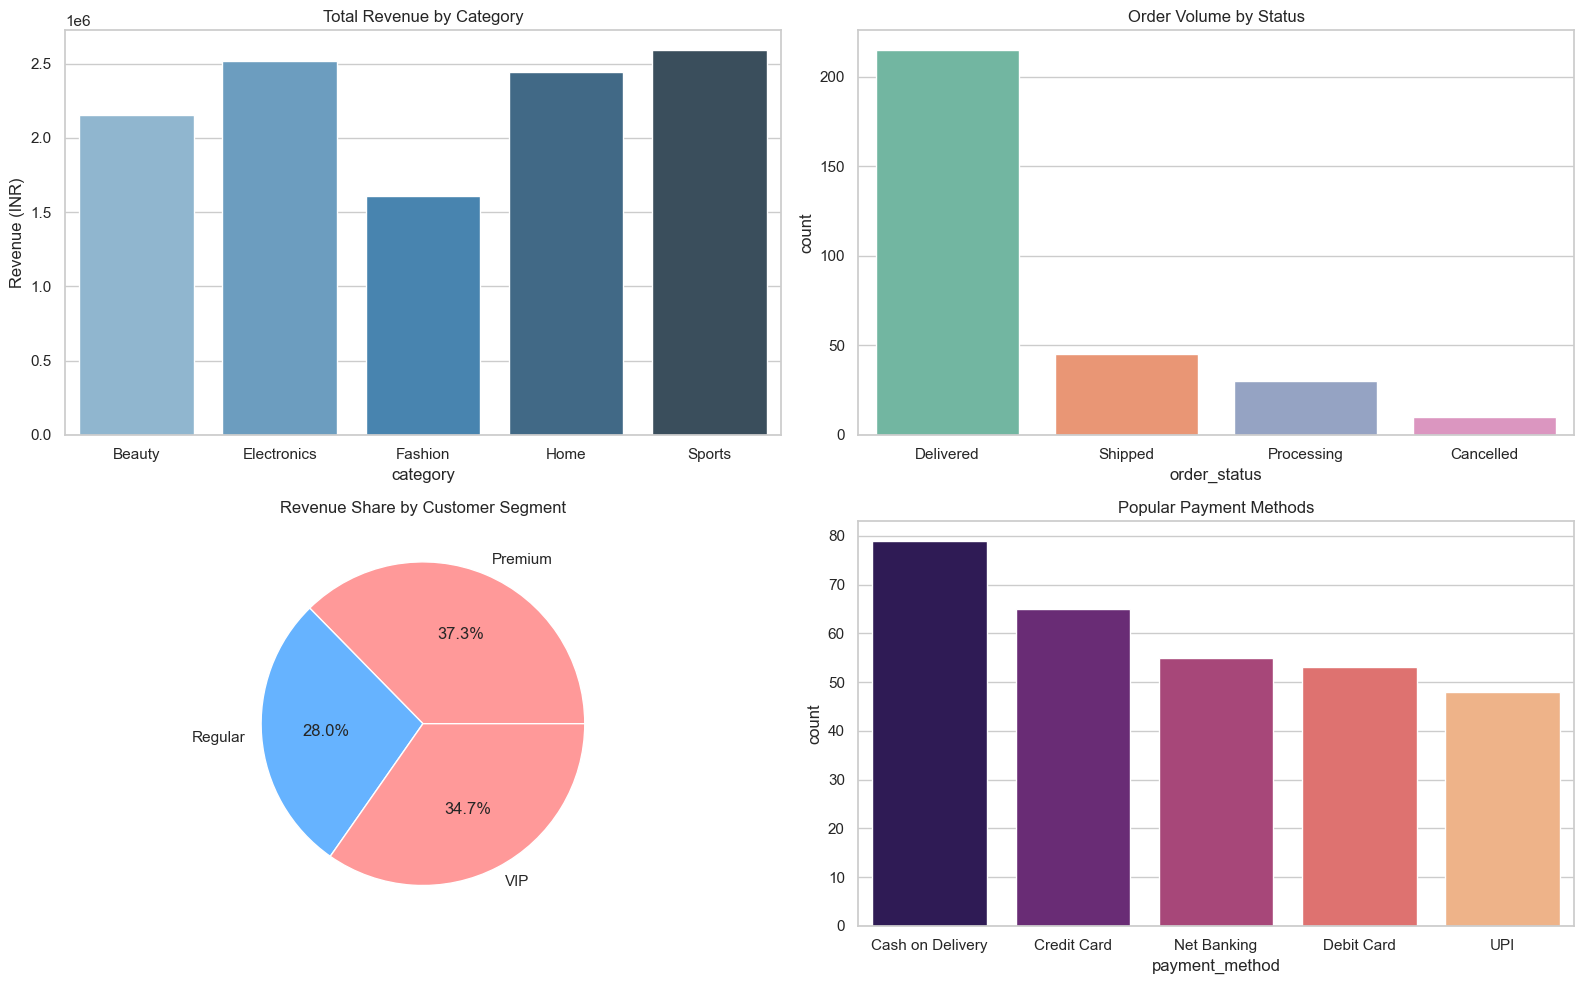

In [20]:
# ==========================================
# VISUALIZATIONS & ADVANCED ANALYTICS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Revenue by Product Category
cat_revenue = master_df.groupby("category")["total_amount"].sum().reset_index()
sns.barplot(data=cat_revenue, x="category", y="total_amount", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Total Revenue by Category")
axes[0, 0].set_ylabel("Revenue (INR)")

# 2. Order Status Breakdown
status_cnt = master_df["order_status"].value_counts().reset_index()
sns.barplot(data=status_cnt, x="order_status", y="count", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Order Volume by Status")

# 3. Revenue by Customer Segment
segment_rev = master_df.groupby("customer_segment")["total_amount"].sum().reset_index()
axes[1, 0].pie(segment_rev["total_amount"], labels=segment_rev["customer_segment"], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1, 0].set_title("Revenue Share by Customer Segment")

# 4. Preferred Payment Methods
pay_cnt = master_df["payment_method"].value_counts().reset_index()
sns.barplot(data=pay_cnt, x="payment_method", y="count", ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Popular Payment Methods")

plt.tight_layout()
plt.show()

In [21]:
# ==========================================
# CLOSE DATABASE CONNECTION
# ==========================================
connection.close()
print("MySQL connection safely closed.")

MySQL connection safely closed.
